- ## Traffic Volume Prediction Using Machine Learning

 - ## 🎯 2. Aim of the Project

### The aim of this project is to build a machine learning model that can accurately predict traffic volume based on historical traffic data and environmental factors such as weather, time, and seasonal patterns.

 - 📌 3. Objectives
 - To analyze traffic patterns using historical data
 - To preprocess and engineer meaningful features (lags, rolling stats, time features)
 - To handle both numerical and categorical data effectively
 - To apply multiple machine learning models and compare their performance
 - To optimize models using hyperparameter tuning
 - To build a robust and scalable prediction pipeline

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

import joblib

## Load Data

In [4]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

In [5]:
df.shape

(48204, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


## Basic Preprocessing

In [7]:
df["holiday"] = df["holiday"].fillna("No Holiday")
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time")


In [8]:
df.duplicated().sum()

np.int64(17)

In [9]:
df = df.drop_duplicates(keep = 'first')

In [10]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

In [11]:
df.isna().sum()/len(df) * 100

holiday                0.0
temp                   0.0
rain_1h                0.0
snow_1h                0.0
clouds_all             0.0
weather_main           0.0
weather_description    0.0
date_time              0.0
traffic_volume         0.0
dtype: float64

In [12]:
# Are there inconsistent or invalid values in any column?
for col in df.select_dtypes(include = "object"):
    print(col,df[col].unique(),df[col].nunique())
    print()

holiday <ArrowStringArray>
[               'No Holiday',              'Columbus Day',
              'Veterans Day',          'Thanksgiving Day',
             'Christmas Day',             'New Years Day',
      'Washingtons Birthday',              'Memorial Day',
          'Independence Day',                'State Fair',
                 'Labor Day', 'Martin Luther King Jr Day']
Length: 12, dtype: str 12

weather_main <ArrowStringArray>
[      'Clouds',        'Clear',         'Rain',      'Drizzle',
         'Mist',         'Haze',          'Fog', 'Thunderstorm',
         'Snow',       'Squall',        'Smoke']
Length: 11, dtype: str 11

weather_description <ArrowStringArray>
[                   'scattered clouds',                       'broken clouds',
                     'overcast clouds',                        'sky is clear',
                          'few clouds',                          'light rain',
             'light intensity drizzle',                                'mist',

In [13]:
df["hour"] = df["date_time"].dt.hour
df["day"] = df["date_time"].dt.day
df["month"] = df["date_time"].dt.month
df["dayofweek"] = df["date_time"].dt.dayofweek

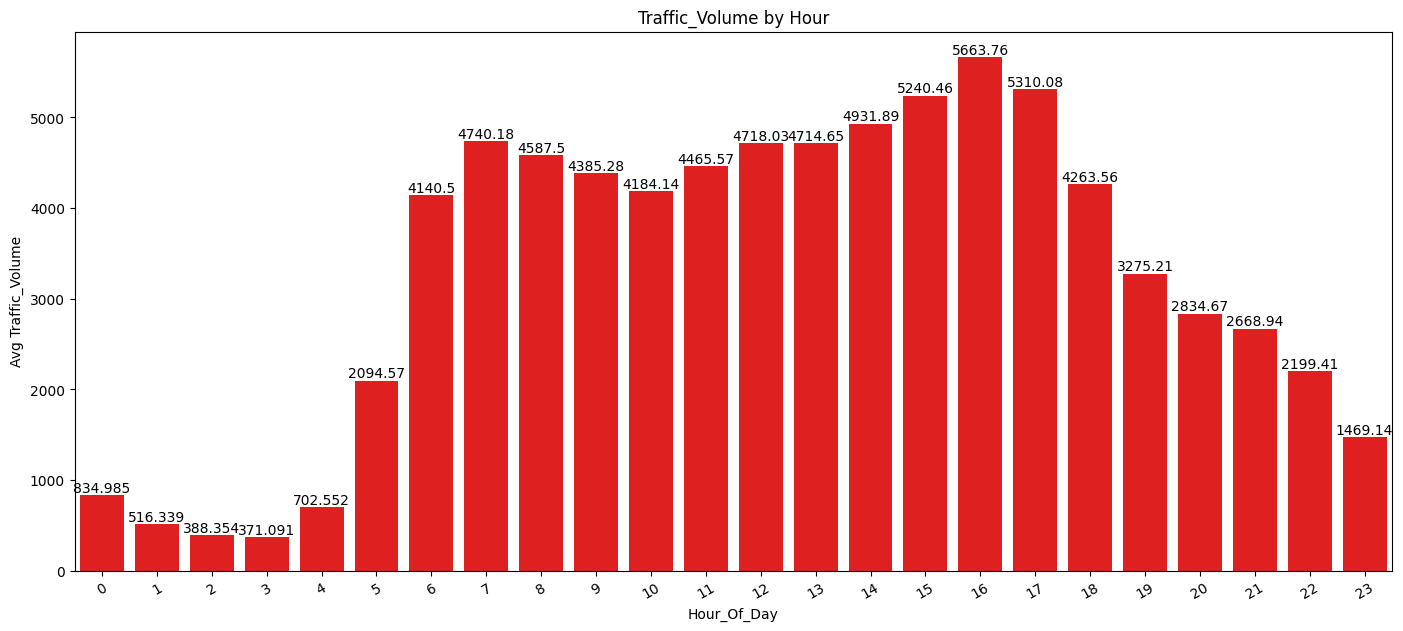

In [14]:
plt.figure(figsize = (17,7))
res = df.groupby(by = ["hour"])[["traffic_volume"]].mean().reset_index()
ax = sns.barplot(data = res,x = "hour",y = "traffic_volume",color = "red")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Traffic_Volume by Hour")
plt.xlabel("Hour_Of_Day")
plt.ylabel("Avg Traffic_Volume")
plt.xticks(rotation = 30)
plt.show()

 -  The bar chart illustrates the average traffic volume across each hour of the day, revealing clear daily traffic patterns. Traffic is minimal during late night and early morning hours (12 AM to 5 AM), reaching its lowest levels between 2 AM and 4 AM, which reflects reduced human activity and minimal commuting. 
 - Starting around 6 AM, there is a sharp increase in traffic, marking the beginning of the morning rush hour, with significant peaks around 7–9 AM due to work and school commutes. During midday (10 AM to 2 PM), traffic remains relatively stable at a high level, indicating consistent urban movement during business hours.
 - The highest traffic volume occurs in the evening, peaking around 4 PM, which corresponds to the end of the workday and increased congestion from return commutes. After 6 PM, traffic gradually declines as the day progresses into the night, dropping significantly by 11 PM.
 - Overall, the pattern highlights two major peak periods—morning and evening rush hours—with the evening peak being the most intense, demonstrating how traffic volume is closely aligned with daily human activity cycles.

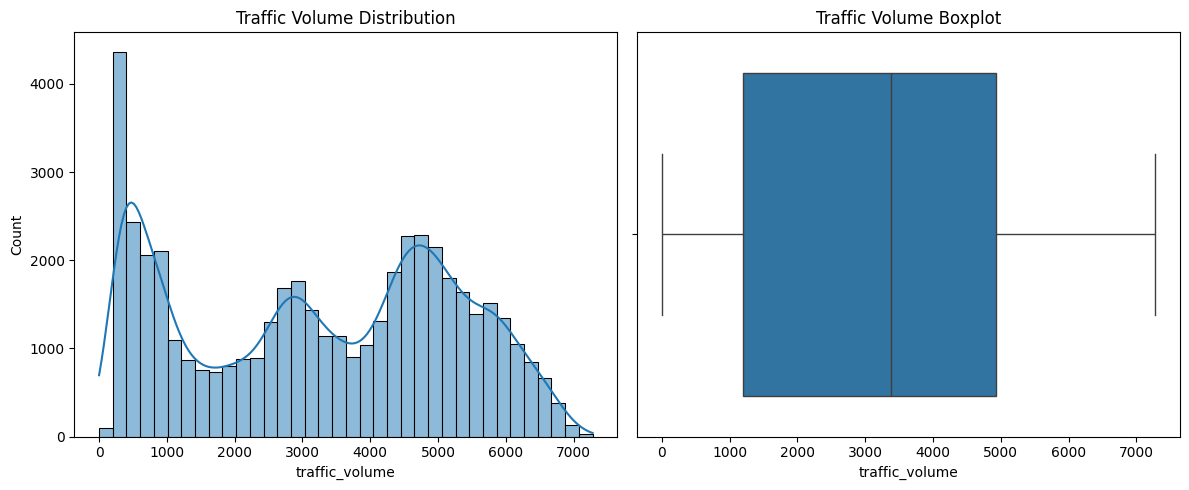

In [15]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['traffic_volume'], kde=True)
plt.title("Traffic Volume Distribution")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['traffic_volume'])
plt.title("Traffic Volume Boxplot")

plt.tight_layout()
plt.show()

 - The traffic volume distribution is not normally distributed and instead shows a clear multi-modal pattern, indicating that traffic varies significantly at different times of the day.
 - There are multiple peaks in the histogram, with lower values around 500–1000 representing low traffic periods such as night or early morning, moderate values around 2500–3500, and higher peaks around 4500–5500 corresponding to rush hours. The distribution is slightly right-skewed, with a tail extending toward higher values up to around 7000, suggesting occasional high traffic spikes.
 -  However, the boxplot shows that these higher values are not true outliers but rather represent real-world peak traffic conditions. The median traffic volume is around 3500, and the wide spread indicates high variability in traffic patterns.
 -  Overall, this distribution reflects structured, time-dependent behavior rather than random noise, meaning these variations are meaningful and should be preserved for modeling rather than removed or overly transformed.

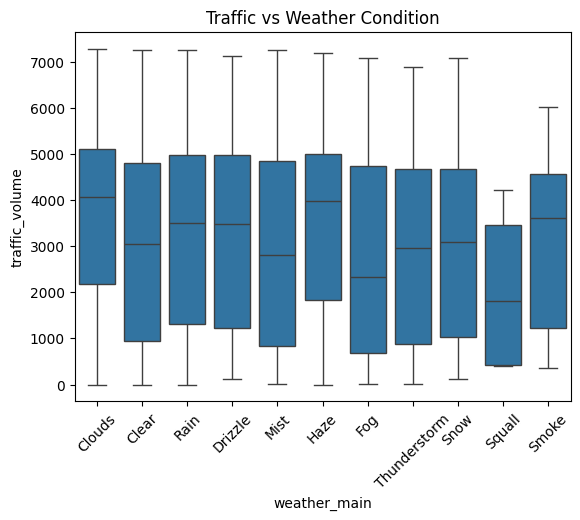

In [16]:
plt.figure()
sns.boxplot(x='weather_main', y='traffic_volume', data=df)
plt.xticks(rotation=45)
plt.title("Traffic vs Weather Condition")
plt.show()

- The provided box plot visualizes how traffic volume is distributed across different weather conditions. For most common categories like Clouds, Clear, Rain, and Haze, the median traffic volume is consistently high, typically staying between 3,000 and 4,000. This suggests that routine weather does not significantly change driving behavior.
 - In contrast, certain conditions like Fog and Mist show a much wider spread, indicating high variability and less predictable traffic patterns. The Squall category is the most notable exception, showing a significantly lower median and overall range. This indicates that extreme, sudden weather events are the primary environmental factor that effectively reduces the number of vehicles on the road.

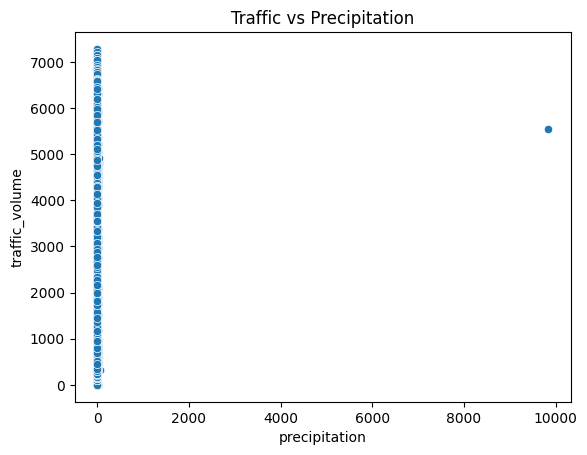

In [17]:
# Create precipitation feature
df['precipitation'] = df['rain_1h'] + df['snow_1h']

plt.figure()
sns.scatterplot(x='precipitation', y='traffic_volume', data=df)
plt.title("Traffic vs Precipitation")
plt.show()

 - This scatter plot reveals a major issue with the data: a massive outlier that is skewing the entire visualization.
 - While the x-axis (precipitation) extends all the way to nearly 10,000, almost every single data point is clustered at or near 0. This suggests that for the vast majority of the time, there is little to no precipitation. The single point on the far right is likely an erroneous data entry or an extreme weather anomaly that makes it impossible to see any actual correlation between normal rain/snow levels and traffic volume.
 - Because of this outlier, the vertical cluster at zero looks like a single thin line, hiding the true distribution of traffic. To fix this and gain meaningful insights, you should filter the data—for example, by removing values where precipitation exceeds a certain threshold (like 100)—or use a logarithmic scale on the x-axis. This would allow you to zoom in on the "messy" part of the data near zero and see if traffic actually drops as precipitation increases.

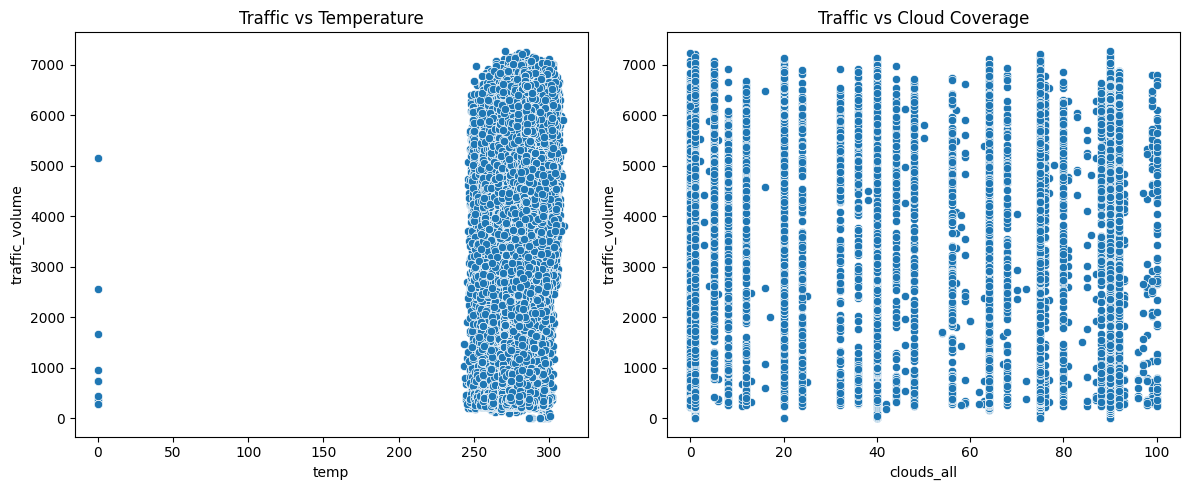

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Temperature vs Traffic
sns.scatterplot(x='temp', y='traffic_volume', data=df, ax=axes[0])
axes[0].set_title("Traffic vs Temperature")

# Clouds vs Traffic
sns.scatterplot(x='clouds_all', y='traffic_volume', data=df, ax=axes[1])
axes[1].set_title("Traffic vs Cloud Coverage")

plt.tight_layout()
plt.show()

 - The Traffic vs Temperature plot shows a dense, uniform cluster of data points across the temperature range. This indicates a weak correlation, as traffic volume spans from 0 to over 7,000 regardless of whether it is cold (240K) or warm (310K). Temperature alone does not appear to be a primary predictor of road activity.

 - The Traffic vs Cloud Coverage plot displays vertical columns, likely due to cloud data being recorded in fixed percentage intervals. Similar to temperature, these columns span the entire y-axis, meaning traffic can be at its highest or lowest point under any cloud condition. Both plots suggest that while weather is a factor, variables like time of day or day of the week likely have a much stronger influence on traffic volume.

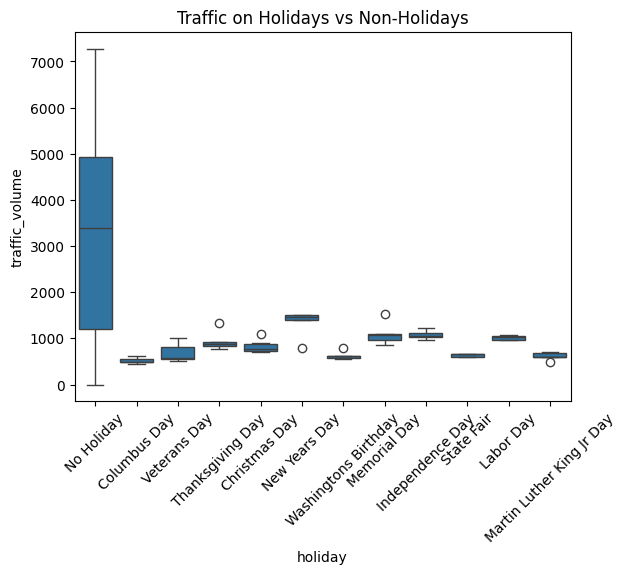

In [19]:
plt.figure()
sns.boxplot(x='holiday', y='traffic_volume', data=df)
plt.xticks(rotation=45)
plt.title("Traffic on Holidays vs Non-Holidays")
plt.show()

 - This box plot demonstrates that holidays have a massive impact on traffic reduction. The "No Holiday" category shows a high median volume of over 3,000 with a very broad spread, reflecting the high variability of standard daily commuting and rush hours.

 - Conversely, all specific holidays—such as Christmas Day, Thanksgiving, and Labor Day—show extremely low and stable traffic volumes, generally staying below 1,000. The compressed size of the holiday boxes indicates that traffic remains consistently light throughout these days, making the "holiday" status one of the most significant predictors for low traffic in this dataset.

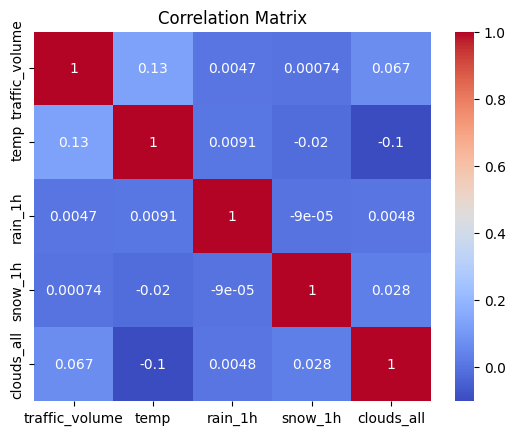

In [20]:
plt.figure()
corr = df[['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

 - This heatmap displays the correlation coefficients between traffic volume and various weather features. The values range from -1 to 1, where 1 represents a perfect positive correlation, -1 a perfect negative correlation, and 0 indicates no linear relationship.

 - The most critical insight is that none of the weather features show a strong linear correlation with traffic volume. The highest correlation for traffic is with temperature (0.13), which is still considered very weak. Other features like rain, snow, and cloud coverage have coefficients near zero (e.g., 0.0047 for rain), confirming that these individual numeric values do not directly dictate traffic flow in a simple linear fashion.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'temp'),
  Text(1, 0, 'rain_1h'),
  Text(2, 0, 'snow_1h'),
  Text(3, 0, 'clouds_all'),
  Text(4, 0, 'traffic_volume'),
  Text(5, 0, 'hour'),
  Text(6, 0, 'day'),
  Text(7, 0, 'month'),
  Text(8, 0, 'dayofweek'),
  Text(9, 0, 'precipitation')])

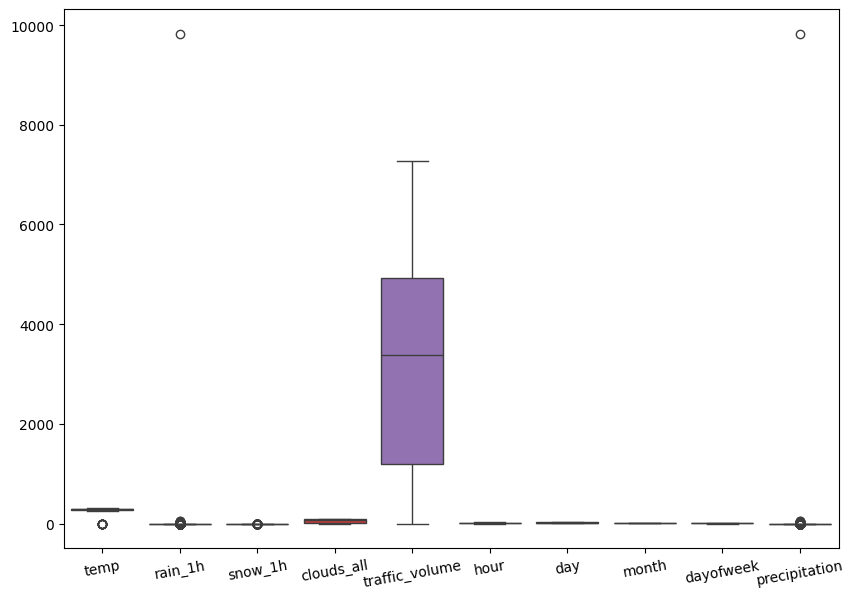

In [21]:
plt.figure(figsize=(10,7))
sns.boxplot(df)
plt.xticks(rotation=10)

In [22]:
num_cols = ["temp"]
!pip install feature_engine
from feature_engine.outliers import Winsorizer
winsor = Winsorizer(capping_method = "iqr",tail = 'both',fold = 1.5)
df[num_cols] = winsor.fit_transform(df[num_cols])


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

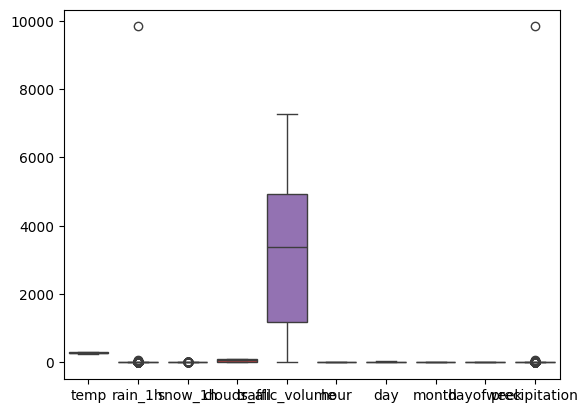

In [23]:
sns.boxplot(df)

In [24]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month,dayofweek,precipitation
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,1,0.0
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,1,0.0
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,1,0.0
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,1,0.0
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,1,0.0


In [25]:
df.dtypes

holiday                           str
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                      str
weather_description               str
date_time              datetime64[us]
traffic_volume                  int64
hour                            int32
day                             int32
month                           int32
dayofweek                       int32
precipitation                 float64
dtype: object

## Feature Engineering

In [26]:
# Cyclical encoding
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)

# Lag features
df["lag_1"] = df["traffic_volume"].shift(1)
df["lag_2"] = df["traffic_volume"].shift(2)
df["lag_24"] = df["traffic_volume"].shift(24)

# Rolling features (NO leakage)
df["rolling_mean_3"] = df["traffic_volume"].shift(1).rolling(3).mean()
df["rolling_mean_6"] = df["traffic_volume"].shift(1).rolling(6).mean()
df["rolling_std_3"] = df["traffic_volume"].shift(1).rolling(3).std()

# Extra features
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18]).astype(int)
df["precipitation"] = df["rain_1h"] + df["snow_1h"]
df["is_holiday"] = (df["holiday"] != "No Holiday").astype(int)


# Drop unused columns
df = df.drop(columns=["holiday", "date_time", "weather_description","precipitation"])

# Remove NaNs from lag/rolling
df = df.iloc[24:].reset_index(drop=True)

In [27]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day,month,dayofweek,...,dow_sin,dow_cos,lag_1,lag_2,lag_24,rolling_mean_3,rolling_mean_6,rolling_std_3,is_rush_hour,is_holiday
0,291.97,0.0,0.0,1,Clear,5097,12,3,10,2,...,0.974928,-0.222521,5471.0,6511.0,5545.0,5885.000000,3592.333333,551.459881,0,0
1,293.23,0.0,0.0,1,Clear,4887,13,3,10,2,...,0.974928,-0.222521,5097.0,5471.0,4516.0,5693.000000,4380.666667,732.674553,0,0
2,294.31,0.0,0.0,1,Clear,5337,14,3,10,2,...,0.974928,-0.222521,4887.0,5097.0,4767.0,5151.666667,5059.500000,295.813004,0,0
3,295.17,0.0,0.0,1,Clear,5692,15,3,10,2,...,0.974928,-0.222521,5337.0,4887.0,5026.0,5107.000000,5496.000000,225.166605,0,0
4,295.13,0.0,0.0,1,Clear,6137,16,3,10,2,...,0.974928,-0.222521,5692.0,5337.0,4918.0,5305.333333,5499.166667,403.433183,1,0


In [28]:
df.dtypes

temp              float64
rain_1h           float64
snow_1h           float64
clouds_all          int64
weather_main          str
traffic_volume      int64
hour                int32
day                 int32
month               int32
dayofweek           int32
hour_sin          float64
hour_cos          float64
month_sin         float64
month_cos         float64
dow_sin           float64
dow_cos           float64
lag_1             float64
lag_2             float64
lag_24            float64
rolling_mean_3    float64
rolling_mean_6    float64
rolling_std_3     float64
is_rush_hour        int64
is_holiday          int64
dtype: object

In [29]:
df = df.drop(columns=["hour","day", "month", "dayofweek"])

In [30]:
df.dtypes

temp              float64
rain_1h           float64
snow_1h           float64
clouds_all          int64
weather_main          str
traffic_volume      int64
hour_sin          float64
hour_cos          float64
month_sin         float64
month_cos         float64
dow_sin           float64
dow_cos           float64
lag_1             float64
lag_2             float64
lag_24            float64
rolling_mean_3    float64
rolling_mean_6    float64
rolling_std_3     float64
is_rush_hour        int64
is_holiday          int64
dtype: object

## Feature Selection

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=["traffic_volume"])
y = df["traffic_volume"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# =====================================
# 2. MUTUAL INFORMATION (NUMERIC ONLY - ANALYSIS)
# =====================================

X_train_num = X_train.select_dtypes(include="number")

mi = mutual_info_regression(X_train_num, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train_num.columns).sort_values(ascending=False)

print("\n=== Mutual Information (Numeric Only) ===")
print(mi_series)


=== Mutual Information (Numeric Only) ===
lag_1             1.779236
hour_cos          0.973096
lag_2             0.952175
hour_sin          0.790934
rolling_mean_3    0.773220
rolling_mean_6    0.472249
temp              0.396271
dow_sin           0.251022
lag_24            0.241096
rolling_std_3     0.238878
is_rush_hour      0.180765
month_cos         0.143629
month_sin         0.138249
dow_cos           0.117208
clouds_all        0.112717
rain_1h           0.065273
is_holiday        0.002864
snow_1h           0.000000
dtype: float64


In [32]:
df = df.drop(columns=[
    "snow_1h",
    "is_holiday"
])

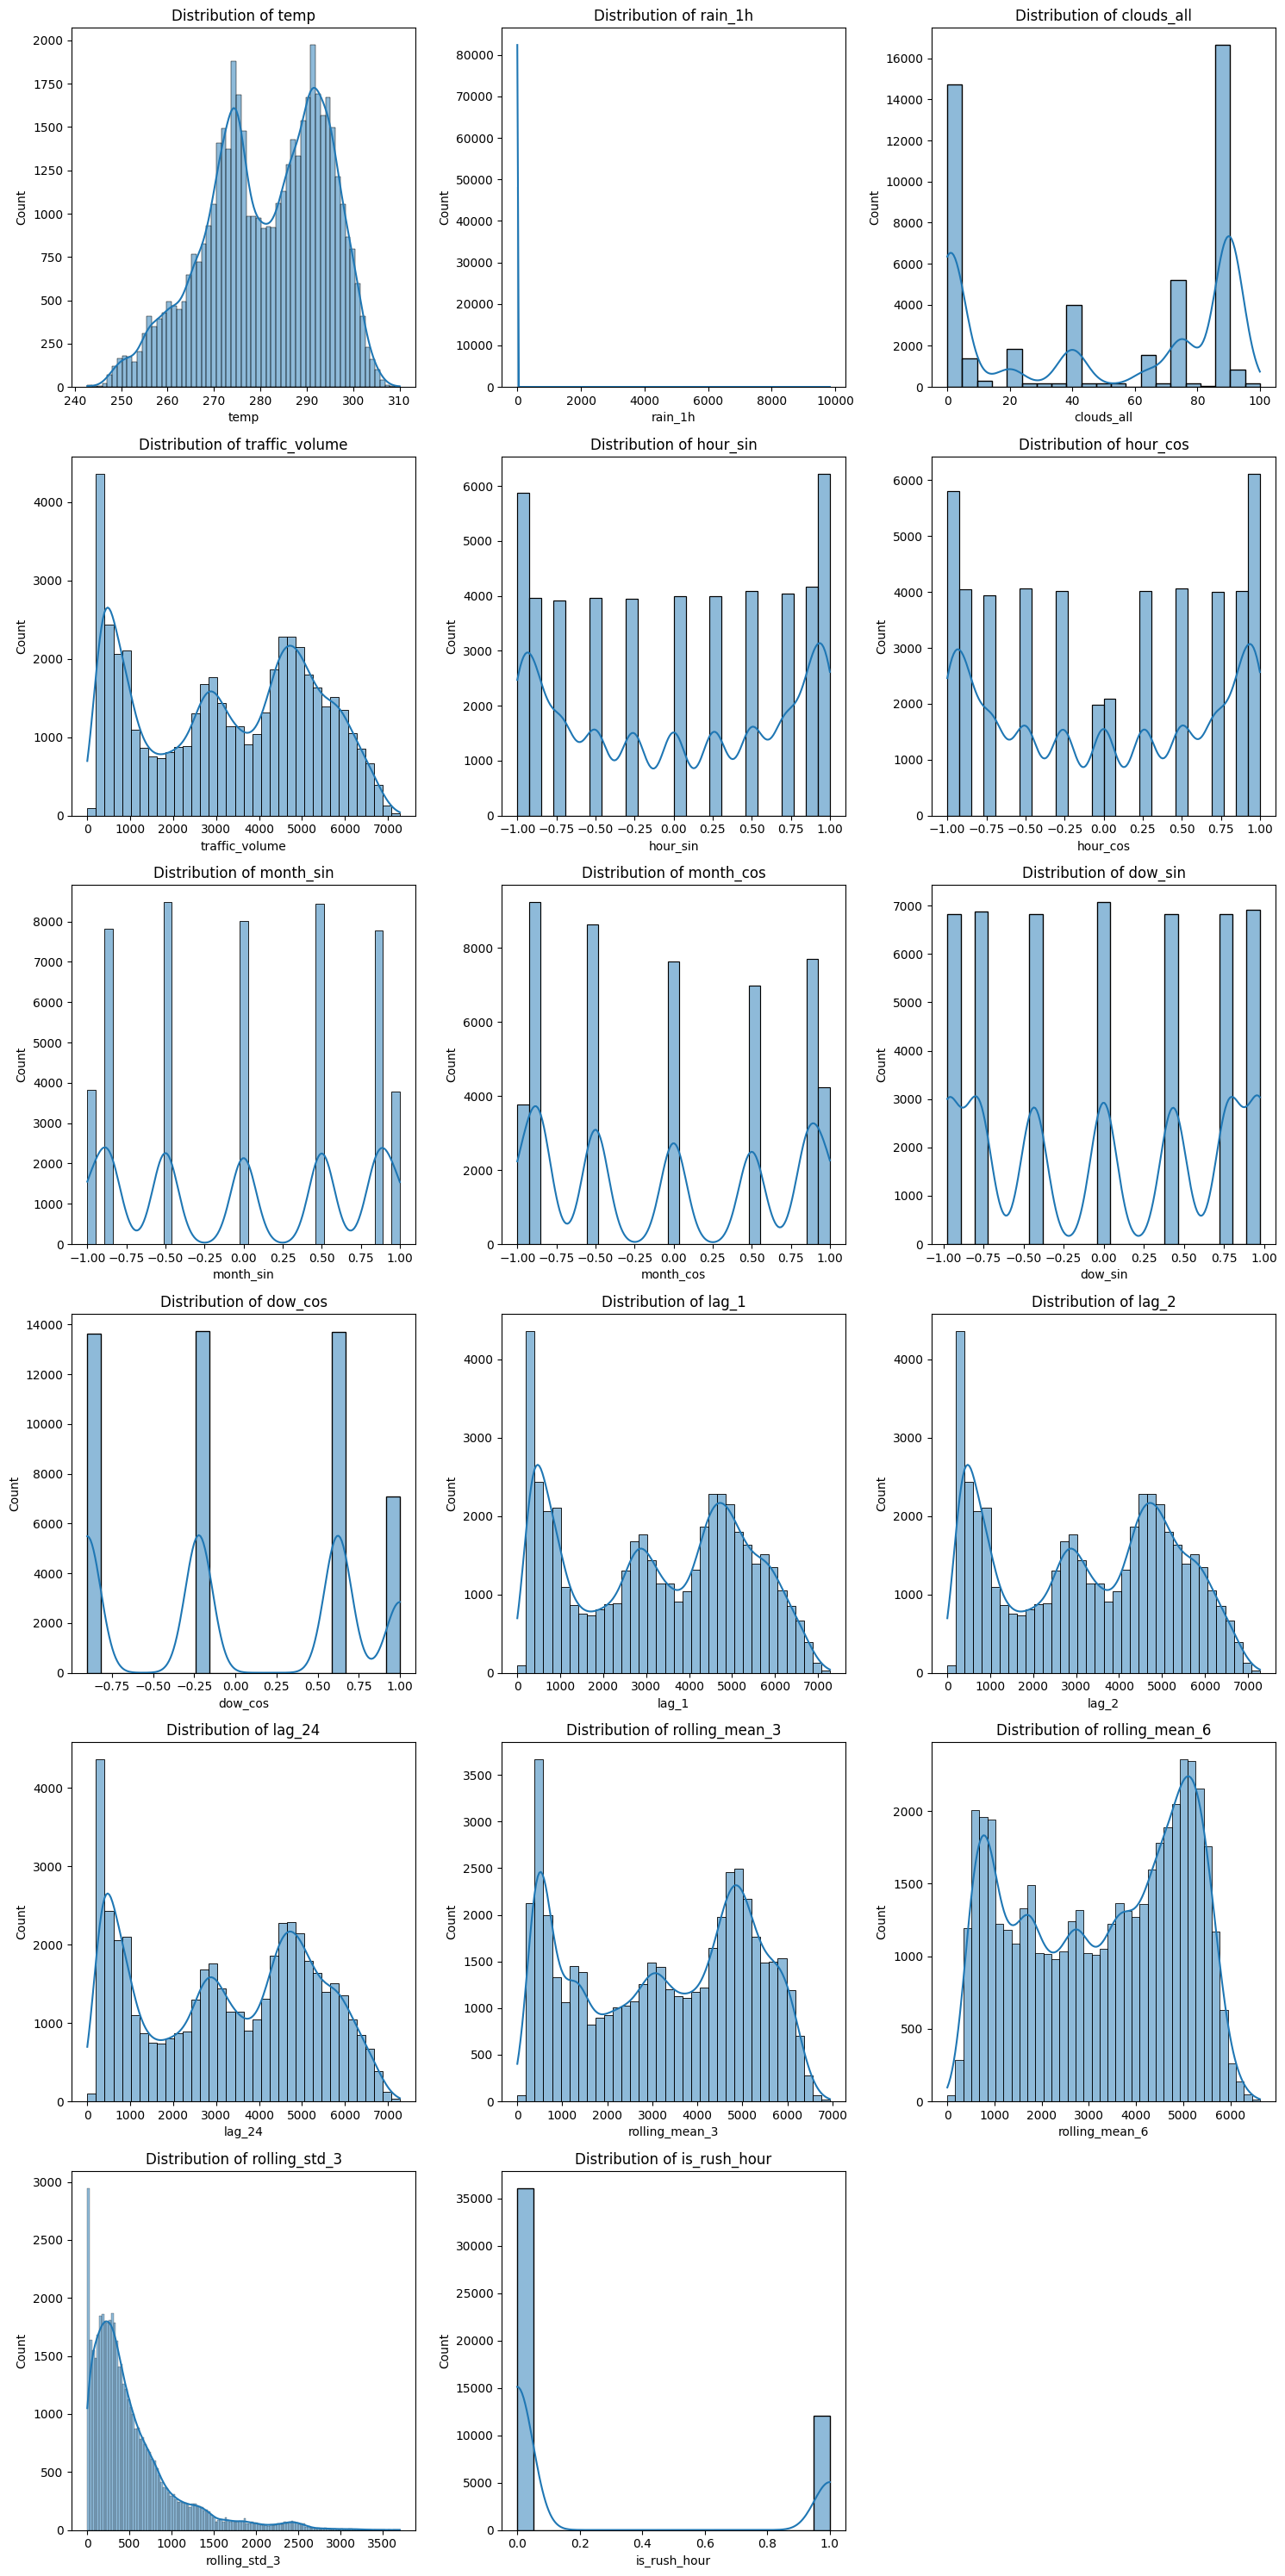

In [33]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set subplot grid
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## Feature Scaling

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

ss_cols = [
    "temp"
]

rs_cols = [
    "rain_1h",
    "clouds_all",
    "lag_1",
    "lag_2",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3"
]

no_scale_cols = [
    "hour_sin","hour_cos",
    "month_sin","month_cos",
    "dow_sin","dow_cos",
    "is_rush_hour"
]

cat_cols = ["weather_main"]

preprocessor = ColumnTransformer(
    transformers=[
        ("std", StandardScaler(), ss_cols),
        ("robust", RobustScaler(), rs_cols),
        ("cat",OneHotEncoder(sparse_output = False,drop = "first",handle_unknown = "ignore"),cat_cols),
        ("passthrough", "passthrough", no_scale_cols)
    ]
)


## Models Defining

In [35]:
models = {
    "Linear": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}


In [36]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predictions
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    
    results.append({
        "Model": name,
        
        # Train metrics
        "Train_R2": r2_score(y_train, train_pred),
        "Train_MAE": mean_absolute_error(y_train, train_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        
        # Test metrics
        "Test_R2": r2_score(y_test, test_pred),
        "Test_MAE": mean_absolute_error(y_test, test_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    })

results_df = pd.DataFrame(results).sort_values(by="Test_R2", ascending=False)

print("\n=== Benchmark Results (Train vs Test) ===")
print(results_df)


=== Benchmark Results (Train vs Test) ===
              Model  Train_R2   Train_MAE  Train_RMSE   Test_R2    Test_MAE  \
5           XGBoost  0.989375  136.355301  205.284835  0.984230  160.866791   
3      RandomForest  0.997271   59.055228  104.034276  0.984227  152.864433   
4  GradientBoosting  0.967340  232.852699  359.908324  0.975265  213.917320   
2      DecisionTree  1.000000    0.000000    0.000000  0.967469  212.494965   
1               KNN  0.954585  273.464931  424.412058  0.937303  330.801744   
0            Linear  0.897403  431.244637  637.899962  0.925778  384.201219   

    Test_RMSE  
5  247.146235  
3  247.163600  
4  309.516604  
2  354.958316  
1  492.781559  
0  536.165045  


## HyperParameter Tuning

In [37]:
# ==============================
# 4. TIME SERIES CV
# ==============================
tscv = TimeSeriesSplit(n_splits=5)

# ==============================
# 5. RANDOM FOREST
# ==============================
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100],
    "model__max_depth": [10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params,
    n_iter=10,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

# ==============================
# 6. GRADIENT BOOSTING
# ==============================
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor())
])

gb_params = {
    "model__n_estimators": [100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]  # works in newer sklearn
}

gb_search = RandomizedSearchCV(
    gb_pipe,
    gb_params,
    n_iter=10,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

# ==============================
# 7. XGBOOST
# ==============================
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, verbosity=0))
])

xgb_params = {
    "model__n_estimators": [100],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.7, 1.0]
}






xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=10,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100], 'model__subsample': [0.7, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... vers

## Model Selection

In [38]:
# ==============================
# 8. COMPARE BEST MODELS
# ==============================
models_best = {
    "RF": rf_search.best_estimator_,
    "GB": gb_search.best_estimator_,
    "XGB": xgb_search.best_estimator_
}

best_score = -np.inf
final_model = None

print("\n=== Model Comparison ===")

for name, model in models_best.items():
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)

    print(f"{name} R2: {score:.4f}")

    if score > best_score:
        best_score = score
        final_model = model



=== Model Comparison ===
RF R2: 0.9841
GB R2: 0.9818
XGB R2: 0.9816


In [39]:
# ==============================
# 9. FINAL EVALUATION
# ==============================
final_pred = final_model.predict(X_test)

print("\n=== Final Model Performance ===")
print("Best Model:", final_model)
print("R2:", r2_score(y_test, final_pred))
print("MAE:", mean_absolute_error(y_test, final_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))



=== Final Model Performance ===
Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['temp']),
                                                 ('robust', RobustScaler(),
                                                  ['rain_1h', 'clouds_all',
                                                   'lag_1', 'lag_2', 'lag_24',
                                                   'rolling_mean_3',
                                                   'rolling_mean_6',
                                                   'rolling_std_3']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                     

In [40]:
# ==============================
# 10. BEST PARAMETERS
# ==============================
print("\n=== Best Parameters ===")
print("RF:", rf_search.best_params_)
print("GB:", gb_search.best_params_)
print("XGB:", xgb_search.best_params_)


=== Best Parameters ===
RF: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': None}
GB: {'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}
XGB: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}


In [43]:
print(results_df.columns)

Index(['Model', 'Train_R2', 'Train_MAE', 'Train_RMSE', 'Test_R2', 'Test_MAE',
       'Test_RMSE'],
      dtype='str')


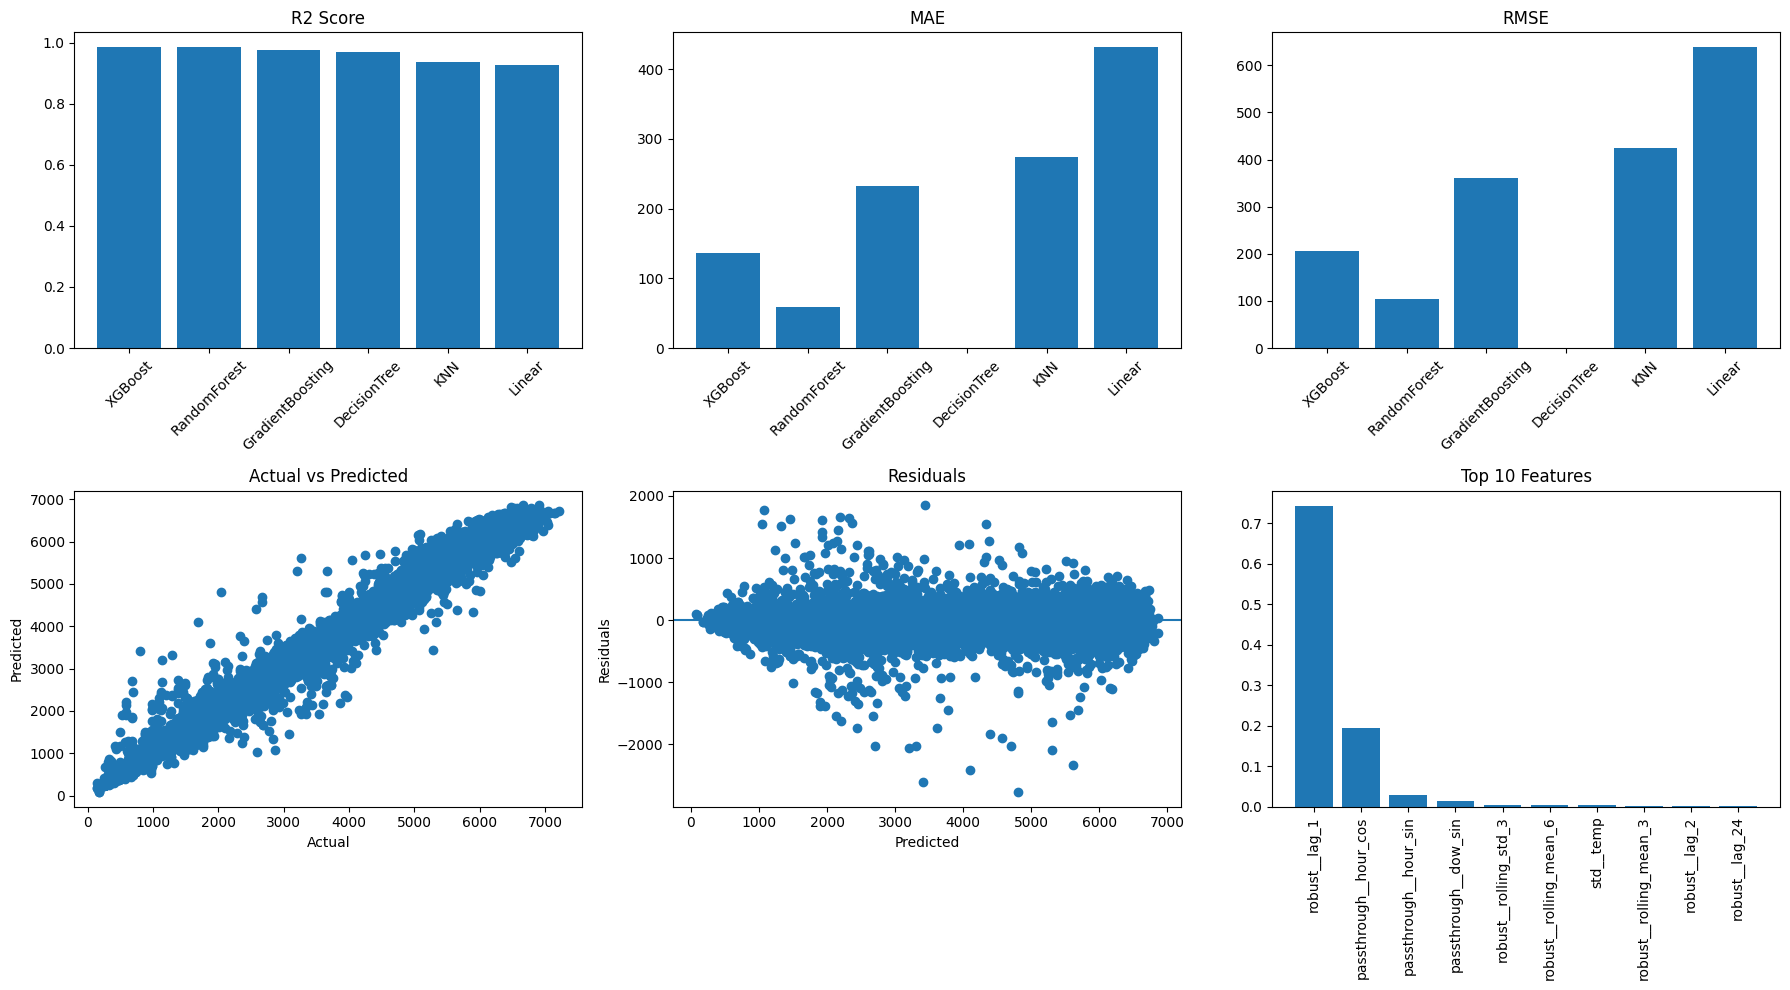

In [45]:
import matplotlib.pyplot as plt

# Predictions
y_pred = final_model.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Feature importance (only works for tree models)
model = final_model.named_steps["model"]
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Handle case where model doesn't support feature_importances_
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top_features = feat_imp.head(10)
else:
    top_features = None

# ==============================
# SUBPLOTS
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 🔹 1. R2 Score
axes[0, 0].bar(results_df["Model"], results_df["Test_R2"])
axes[0, 0].set_title("R2 Score")
axes[0, 0].tick_params(axis='x', rotation=45)

# 🔹 2. MAE
axes[0, 1].bar(results_df["Model"], results_df["Train_MAE"])
axes[0, 1].set_title("MAE")
axes[0, 1].tick_params(axis='x', rotation=45)

# 🔹 3. RMSE
axes[0, 2].bar(results_df["Model"], results_df["Train_RMSE"])
axes[0, 2].set_title("RMSE")
axes[0, 2].tick_params(axis='x', rotation=45)

# 🔹 4. Actual vs Predicted
axes[1, 0].scatter(y_test, y_pred)
axes[1, 0].set_title("Actual vs Predicted")
axes[1, 0].set_xlabel("Actual")
axes[1, 0].set_ylabel("Predicted")

# 🔹 5. Residual Plot
axes[1, 1].scatter(y_pred, residuals)
axes[1, 1].axhline(y=0)
axes[1, 1].set_title("Residuals")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residuals")

# 🔹 6. Feature Importance (if available)
if top_features is not None:
    axes[1, 2].bar(top_features.index, top_features.values)
    axes[1, 2].set_title("Top 10 Features")
    axes[1, 2].tick_params(axis='x', rotation=90)
else:
    axes[1, 2].text(0.5, 0.5, "No Feature Importance",
                    ha='center', va='center')
    axes[1, 2].set_title("Feature Importance")

# Layout adjustment
plt.tight_layout()
plt.show()

## 1. Model Performance Comparison
- 🔹 R² Score Plot
 - Displays how well each model explains the variance in traffic volume.
 - Values are close to 1, indicating strong predictive performance.
 - Random Forest and XGBoost show the highest R² scores, making them the most accurate models.
- 🔹 MAE (Mean Absolute Error)
Measures the average prediction error.
Lower values indicate better performance.
Random Forest and XGBoost again perform best with the lowest MAE.
- 🔹 RMSE (Root Mean Squared Error)
 - Penalizes larger errors more than MAE.
 - Confirms consistency of model performance.
 - Tree-based models outperform simpler models like Linear Regression and KNN.
## 📊 2. Actual vs Predicted Plot
 - This scatter plot compares actual traffic values with predicted values.
 - Most points lie close to the diagonal trend, indicating:
 - High prediction accuracy
 - Strong model fit
- 🔍 Insight:
The model captures overall traffic patterns effectively.
 - Slight dispersion indicates minor prediction errors at extreme values.
## 📉 3. Residual Analysis
 - Residuals = Actual − Predicted values.
 - The plot shows residuals distributed around zero.
 - 🔍 Insights:
 - Random scatter suggests the model is not biased.
 - No clear pattern indicates:
 - Good model generalization
 - Some outliers exist, especially at higher traffic values.
## 📊 4. Feature Importance Analysis
 - Displays the top 10 most influential features used by the model.
 - 🔍 Key Observations:
 - Lag features (e.g., lag_1) are the most important
 - → Past traffic strongly influences future traffic
 - Time-based features (hour encoding) also contribute significantly
 - Weather-related features have relatively lower importance

## SAVE MODEL

In [46]:
joblib.dump(final_model, "final_traffic_model.pkl")

print("\n✅ FINAL MODEL SAVED SUCCESSFULLY!")


✅ FINAL MODEL SAVED SUCCESSFULLY!


## Test Input

In [47]:
import pandas as pd

test_data = pd.DataFrame([{
    "temp": 290.5,
    "rain_1h": 0.0,
    "clouds_all": 75,
    "lag_1": 3200,
    "lag_2": 3000,
    "lag_24": 2800,
    "rolling_mean_3": 3100,
    "rolling_mean_6": 3050,
    "rolling_std_3": 120,

    "hour_sin": 0.5,
    "hour_cos": 0.86,
    "month_sin": 0.0,
    "month_cos": 1.0,
    "dow_sin": 0.0,
    "dow_cos": 1.0,
    "is_rush_hour": 1,

    "weather_main": "Clouds"
}])

In [49]:
prediction = final_model.predict(test_data)

print("Predicted Traffic Volume:", prediction[0])

Predicted Traffic Volume: 1697.0529246031742
